In [20]:
path = "/Users/philipp/projects/gfm/prodigy/scripts/experiments/analysis/best_pretrain_strat/data/experiment_results_Jun_25.tsv"

In [392]:
import pandas as pd
df = pd.read_csv(path, sep="\t")

In [223]:
import pandas as pd

# If train_id became the index:
if "train_id" not in df.columns:
    df = df.reset_index().rename(columns={"index": "train_id"})

eval_cols = [c for c in df.columns if c != "train_id"]

# Maps abbreviated names in the three-way merge to full graph names.
merged_graph_aliases = {
    "ukr": "ukr_rus_twitter",
    "cov": "covid19_twitter",
    "mid": "midterm",
}


def parse_stage(stage):
    """Parse 'graph+task', splitting at the final '+'."""
    graph, task = stage.rsplit("+", 1)
    return {"id": stage, "graph": graph, "task": task}


def parse_train_id(train_id):
    stages = [parse_stage(x) for x in train_id.split(">")]
    return {
        "train_id": train_id,
        "stages": stages,
        "n_stages": len(stages),
        "first": stages[0],
        "last": stages[-1],
    }


models = {
    train_id: parse_train_id(train_id)
    for train_id in df["train_id"]
}

scores = df.set_index("train_id")[eval_cols]


def add_comparison(rows, effect, treatment, control, **metadata):
    """Add treatment - control for every evaluation graph/task."""
    if treatment not in scores.index or control not in scores.index:
        return

    delta = scores.loc[treatment] - scores.loc[control]

    for eval_id, value in delta.items():
        eval_graph, eval_task = eval_id.rsplit("+", 1)

        rows.append({
            "effect": effect,
            "eval_id": eval_id,
            "test_graph": eval_graph,
            "test_task": eval_task,
            "treatment": treatment,
            "control": control,
            "treatment_score": scores.loc[treatment, eval_id],
            "control_score": scores.loc[control, eval_id],
            "delta": value,
            **metadata,
        })


rows = []

# -------------------------------------------------------------------
# 1. Training sequentially on another graph
#
# a+t > b+t versus b+t
# -------------------------------------------------------------------
for treatment, model in models.items():
    if model["n_stages"] != 2:
        continue

    first = model["first"]
    last = model["last"]

    if first["task"] == last["task"]:
        add_comparison(
            rows,
            effect="sequential_graph",
            treatment=treatment,
            control=last["id"],
            source_graph=first["graph"],
            target_graph=last["graph"],
            source_task=first["task"],
            target_task=last["task"],
        )


# -------------------------------------------------------------------
# 2. Training sequentially on another task
#
# a+t1 > b+t2 versus a+t2 > b+t2
#
# This controls for the graph sequence and changes only the task used
# during the first training stage.
# -------------------------------------------------------------------
for treatment, model in models.items():
    if model["n_stages"] != 2:
        continue

    first = model["first"]
    last = model["last"]

    if first["task"] != last["task"]:
        control = f"{first['graph']}+{last['task']}>{last['id']}"

        add_comparison(
            rows,
            effect="sequential_source_task",
            treatment=treatment,
            control=control,
            source_graph=first["graph"],
            target_graph=last["graph"],
            source_task=first["task"],
            control_source_task=last["task"],
            target_task=last["task"],
        )


# -------------------------------------------------------------------
# 3. Training on merged graphs
#
# a/b/c+t versus each available component graph trained on t.
# This produces one comparison per single-graph control.
# -------------------------------------------------------------------
for treatment, model in models.items():
    if model["n_stages"] != 1:
        continue

    stage = model["first"]

    # "/" in graph means graph merge; "/" in task means task merge.
    if "/" not in stage["graph"] or "/" in stage["task"]:
        continue

    components = stage["graph"].split("/")

    for component in components:
        control_graph = merged_graph_aliases.get(component, component)
        control = f"{control_graph}+{stage['task']}"

        add_comparison(
            rows,
            effect="merged_graphs",
            treatment=treatment,
            control=control,
            source_graph=stage["graph"],
            target_graph=control_graph,
            source_task=stage["task"],
            target_task=stage["task"],
        )


# -------------------------------------------------------------------
# 4. Training on another task jointly
#
# graph+nm/fm versus graph+nm
# The first listed task is used as the control.
# -------------------------------------------------------------------
for treatment, model in models.items():
    if model["n_stages"] != 1:
        continue

    stage = model["first"]

    if "/" not in stage["task"]:
        continue

    component_tasks = stage["task"].split("/")
    control_task = component_tasks[0]
    control = f"{stage['graph']}+{control_task}"

    add_comparison(
        rows,
        effect="joint_tasks",
        treatment=treatment,
        control=control,
        source_graph=stage["graph"],
        target_graph=stage["graph"],
        source_task=stage["task"],
        control_source_task=control_task,
        target_task=stage["task"],
    )


effects = pd.DataFrame(rows)

effects = effects.sort_values(
    ["effect", "treatment", "control", "test_graph", "test_task"]
).reset_index(drop=True)

effects.sample(5)

,effect,eval_id,test_graph,test_task,treatment,control,treatment_score,control_score,delta,source_graph,target_graph,source_task,target_task,control_source_task
42,merged_graphs,midterm+lp,midterm,lp,ukr/cov/mid+lp,ukr_rus_twitter+lp,0.664000,0.766250,-0.102250,ukr/cov/mid,ukr_rus_twitter,lp,lp,NaN
75,merged_graphs,covid_political+pl,covid_political,pl,ukr/cov/mid+nm,ukr_rus_twitter+nm,0.597000,0.629334,-0.032334,ukr/cov/mid,ukr_rus_twitter,nm,nm,NaN
9,joint_tasks,ukr_rus_suspended+pl,ukr_rus_suspended,pl,ukr/cov/mid+nm/fm,ukr/cov/mid+nm,0.532000,0.488000,0.044000,ukr/cov/mid,ukr/cov/mid,nm/fm,nm/fm,nm
130,sequential_graph,ukr_rus_twitter+lp,ukr_rus_twitter,lp,midterm+lp>ukr_rus_twitter+lp,ukr_rus_twitter+lp,0.907367,0.921011,-0.013644,midterm,ukr_rus_twitter,lp,lp,NaN
54,merged_graphs,midterm+lp,midterm,lp,ukr/cov/mid+nm,covid19_twitter+nm,0.740000,0.818809,-0.078809,ukr/cov/mid,covid19_twitter,nm,nm,NaN


In [224]:
delta_table = effects.pivot_table(
    index=["effect", "treatment", "control"],
    columns="eval_id",
    values="delta",
)

# delta_table['mean'] = delta_table.mean(axis=1)

delta_table.style.background_gradient(
    cmap="RdYlGn",
    vmin=-effects["delta"].abs().max(),
    vmax=effects["delta"].abs().max(),
).format("{:+.3f}")

In [43]:
d = delta_table.groupby(['effect', 'treatment']).mean()
d['mean'] = d.mean(axis=1)
d.style.background_gradient(
    cmap="RdYlGn",
    vmin=-effects["delta"].abs().max(),
    vmax=effects["delta"].abs().max(),
).format("{:+.3f}")

In [225]:
import pandas as pd
import plotly.express as px
import numpy as np

plot_df = df.melt(
    id_vars="train_id",
    var_name="eval_task",
    value_name="auc",
)

same_task = plot_df["train_id"] == plot_df["eval_task"]
plot_df.loc[same_task, "auc"] = np.nan

fig = px.line(
    plot_df,
    x="eval_task",
    y="auc",
    color="train_id",
    markers=True,
    hover_data={
        "train_id": True,
        "eval_task": True,
        "auc": ":.4f",
    },
    labels={
        "eval_task": "Evaluation task",
        "auc": "AUC",
        "train_id": "Train ID",
    },
    title="AUC by Evaluation Task",
    height=750,
)

fig.update_layout(
    hovermode="closest",
    yaxis_range=[0.45, 1.01],
    xaxis_tickangle=-45,
    legend=dict(groupclick="toggleitem"),
)

post_script = """
const gd = document.getElementById('{plot_id}');
let previousVisibility = null;

gd.querySelectorAll('.legend .traces').forEach((item, index) => {
    item.addEventListener('mouseenter', () => {
        previousVisibility = gd.data.map(
            trace => trace.visible === undefined ? true : trace.visible
        );

        const visibility = gd.data.map(
            (_, i) => i === index ? true : 'legendonly'
        );

        Plotly.restyle(gd, {visible: visibility});
    });

    item.addEventListener('mouseleave', () => {
        if (previousVisibility !== null) {
            Plotly.restyle(gd, {visible: previousVisibility});
            previousVisibility = null;
        }
    });
});
"""

fig.write_html(
    "auc_by_eval_task.html",
    post_script=post_script,
)
fig.show()

In [253]:
sdf = df[~df.train_id.str.contains("\>|/", regex=True)].set_index('train_id')
sdf.index = sdf.index.str.replace("covid19_twitter", "covid")
sdf.index = sdf.index.str.replace("ukr_rus_twitter", "ukraine")
sdf.index = sdf.index.str.replace("midterm", "midterm")

In [254]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# df.index = train IDs; df.columns = test IDs
long = (
    sdf.rename_axis("train_id")
      .rename_axis("test_id", axis=1)
      .stack()
      .rename("auc")
      .reset_index()
)

long[["train_graph", "train_task"]] = (
    long["train_id"].str.rsplit("+", n=1, expand=True)
)

long[["test_graph", "test_task"]] = (
    long["test_id"].str.rsplit("+", n=1, expand=True)
)

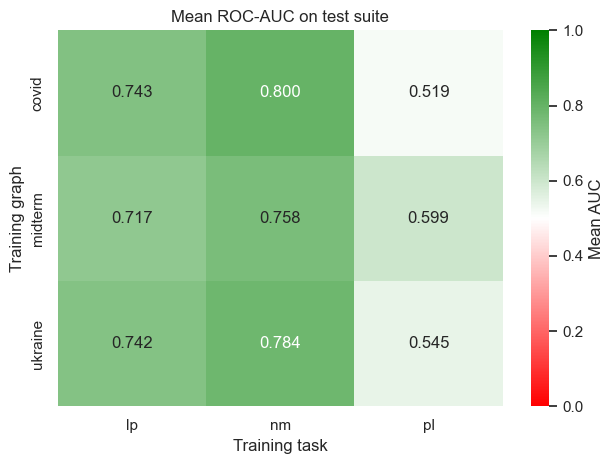

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

graph_effect = long.pivot_table(
    index="train_graph",
    columns="train_task",
    values="auc",
    aggfunc="mean"
)

# graph_effect['mean'] = graph_effect.mean(axis=1)

cmap = LinearSegmentedColormap.from_list(
    "red_white_green",
    ["red", "white", "green"]
)

norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)

ax = sns.heatmap(
    graph_effect,
    annot=True,
    fmt=".3f",
    cmap=cmap,
    norm=norm,
    cbar_kws={"label": "Mean AUC"}
)

ax.set_xlabel("Training task")
ax.set_ylabel("Training graph")
ax.set_title("Mean ROC-AUC on test suite")

plt.tight_layout()
plt.show()

In [305]:
long.auc.mask(~long.train_task.eq('nm'), 0)

0      0.000000
1      0.887047
2      0.000000
3      0.000000
4      0.764309
         ...   
103    0.972005
104    0.000000
105    0.000000
106    0.991267
107    0.000000
Name: auc, Length: 108, dtype: float64

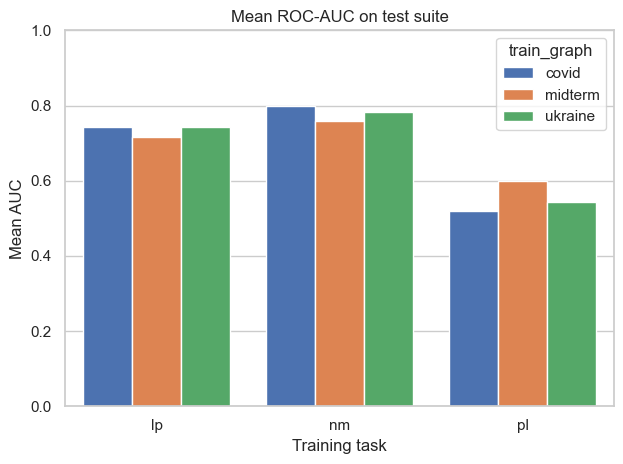

In [327]:
palette = {
    "nm": (0.2, 0.5, 0.8, 0),
    "pl": (0.9, 0.4, 0.2, 0),
    "lp": (0.2, 0.7, 0.3, 1.0),
}

only = long.copy()
# only.loc[only["train_task"] != "lp", "auc"] = np.nan
# only.loc[only["train_graph"] != "covid", "auc"] = np.nan


sns.barplot(
    data=only,
    x="train_task",
    y="auc",
    hue="train_graph",
    # palette=palette,
    saturation=1,
    errorbar=None,
)

plt.xlabel("Training task")
plt.ylabel("Mean AUC")
plt.title("Mean ROC-AUC on test suite")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
long.groupby('')

,train_id,test_id,auc,train_graph,train_task,test_graph,test_task,graph_choice,task_choice,same_graph,same_task
0,covid+lp,covid19_twitter+lp,0.955070,covid,lp,covid19_twitter,lp,covid → covid19_twitter,lp → lp,False,True
1,covid+nm,covid19_twitter+lp,0.887047,covid,nm,covid19_twitter,lp,covid → covid19_twitter,nm → lp,False,False
2,covid+pl,covid19_twitter+lp,0.527322,covid,pl,covid19_twitter,lp,covid → covid19_twitter,pl → lp,False,False
3,midterm+lp,covid19_twitter+lp,0.604596,midterm,lp,covid19_twitter,lp,midterm → covid19_twitter,lp → lp,False,True
4,midterm+nm,covid19_twitter+lp,0.764309,midterm,nm,covid19_twitter,lp,midterm → covid19_twitter,nm → lp,False,False
...,...,...,...,...,...,...,...,...,...,...,...
103,midterm+nm,ukr_rus_twitter+nm,0.972005,midterm,nm,ukr_rus_twitter,nm,midterm → ukr_rus_twitter,nm → nm,False,True
104,midterm+pl,ukr_rus_twitter+nm,0.650987,midterm,pl,ukr_rus_twitter,nm,midterm → ukr_rus_twitter,pl → nm,False,False
105,ukraine+lp,ukr_rus_twitter+nm,0.947754,ukraine,lp,ukr_rus_twitter,nm,ukraine → ukr_rus_twitter,lp → nm,False,False
106,ukraine+nm,ukr_rus_twitter+nm,0.991267,ukraine,nm,ukr_rus_twitter,nm,ukraine → ukr_rus_twitter,nm → nm,False,True


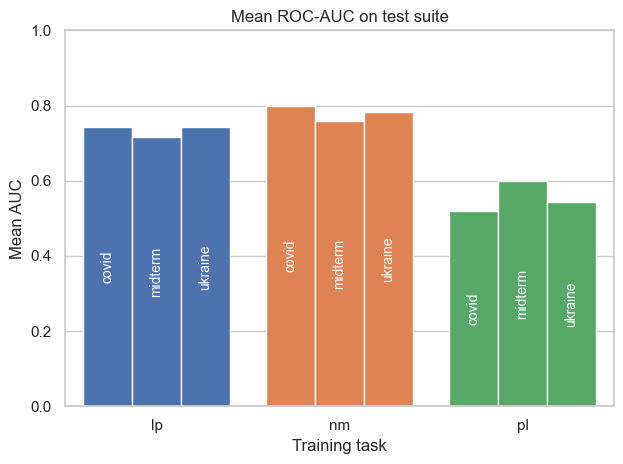

In [341]:
order_task  = ["lp", "nm", "pl"]
order_graph = ["covid", "midterm", "ukraine"]

pal = sns.color_palette()
task_colors = {"lp": pal[0], "nm": pal[1], "pl": pal[2]}

ax = sns.barplot(
    data=only,
    x="train_task",
    y="auc",
    hue="train_graph",
    order=order_task,
    hue_order=order_graph,
    saturation=1,
    errorbar=None,
)

# recolor each bar by its task-cluster
for patch in ax.patches:
    center = patch.get_x() + patch.get_width() / 2
    task = order_task[int(round(center))]
    patch.set_facecolor(task_colors[task])

# label each bar with its graph name (one container per hue level)
for container, graph in zip(ax.containers, order_graph):
    ax.bar_label(
        container,
        labels=[graph] * len(container),
        label_type="center",   # inside the bar
        rotation=90,
        color="white",
        fontsize=10,
    )

ax.get_legend().remove()

plt.xlabel("Training task")
plt.ylabel("Mean AUC")
plt.title("Mean ROC-AUC on test suite")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Text(47.24999999999999, 0.5, 'Train graph+task ')

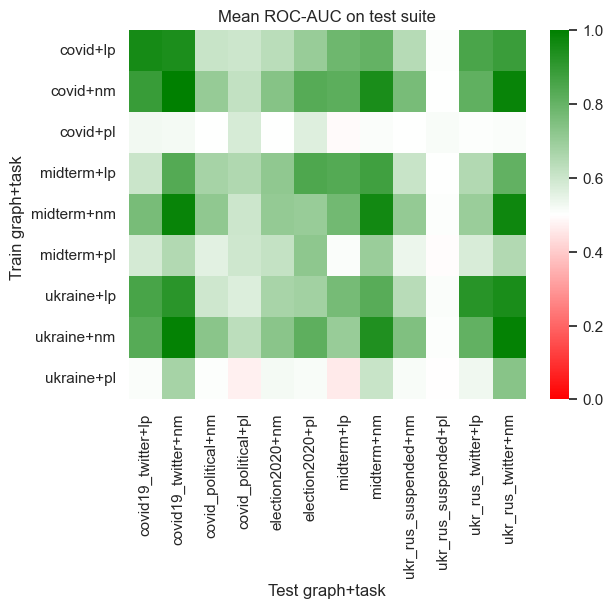

In [256]:
sns.heatmap(sdf, annot=False, fmt=".3f", cmap=cmap, vmin=0, vmax=1)
plt.title("Mean ROC-AUC on test suite")
plt.xlabel("Test graph+task")
plt.ylabel("Train graph+task ")

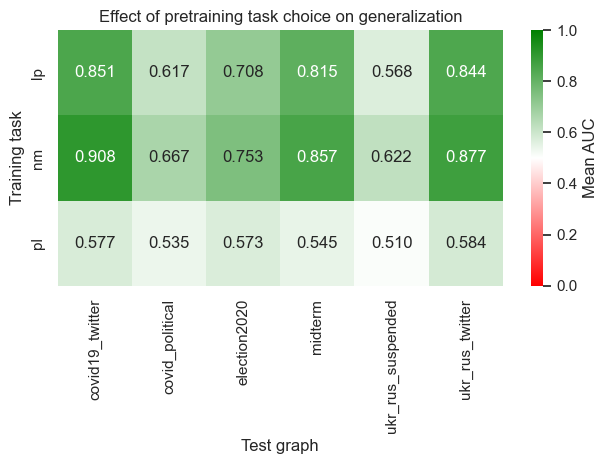

In [257]:
task_effect = long.pivot_table(
    index="train_task",
    columns="test_graph",
    values="auc",
    aggfunc="mean"
)

ax = sns.heatmap(
    task_effect,
    annot=True,
    fmt=".3f",
    cmap=cmap,
    norm=norm,
    cbar_kws={"label": "Mean AUC"}
)

ax.set_xlabel("Test graph")
ax.set_ylabel("Training task")
ax.set_title("Effect of pretraining task choice on generalization")

plt.tight_layout()
plt.show()

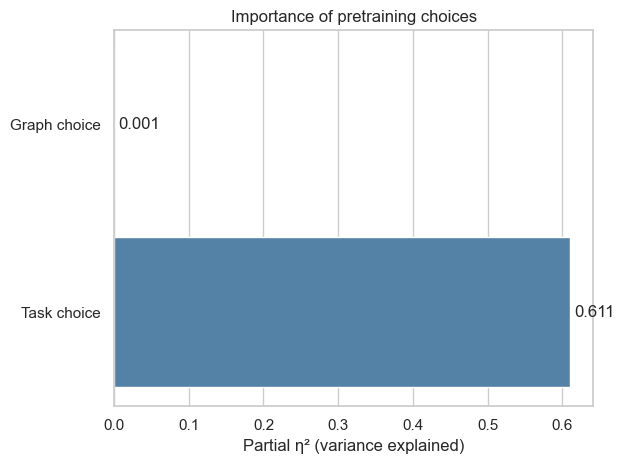

In [258]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

factor_cols = [
    "train_graph",
    "train_task",
    "test_graph",
    "test_task",
]

model_data = long.copy()

model_data[factor_cols] = model_data[factor_cols].astype(object)
model_data["auc"] = pd.to_numeric(model_data["auc"], errors="coerce")
model_data = model_data.dropna(subset=factor_cols + ["auc"])

model = smf.ols(
    """
    auc ~ C(train_graph)
          + C(train_task)
          + C(test_graph)
          + C(test_task)
    """,
    data=model_data
).fit()

anova = sm.stats.anova_lm(model, typ=2)

# Partial eta squared
anova["partial_eta2"] = (
    anova["sum_sq"] /
    (anova["sum_sq"] + anova.loc["Residual", "sum_sq"])
)

effects = (
    anova.loc[
        ["C(train_graph)", "C(train_task)"],
        ["partial_eta2"]
    ]
    .rename(index={
        "C(train_graph)": "Graph choice",
        "C(train_task)": "Task choice"
    })
    .reset_index(names="factor")
)

ax = sns.barplot(
    data=effects,
    x="partial_eta2",
    y="factor",
    color="steelblue"
)

ax.set_xlabel("Partial η² (variance explained)")
ax.set_ylabel("")
ax.set_title("Importance of pretraining choices")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
    
plt.tight_layout()
plt.show()

,Source,Share
0,Graph choice,28.4%
1,Task choice,56.2%
2,Other / interactions / noise,15.5%


Within the variation explained by graph and task:
Graph: 33.6%
Task:  66.4%


,Comparison,AUC difference
0,Same graph,+0.091
1,Same task,+0.111


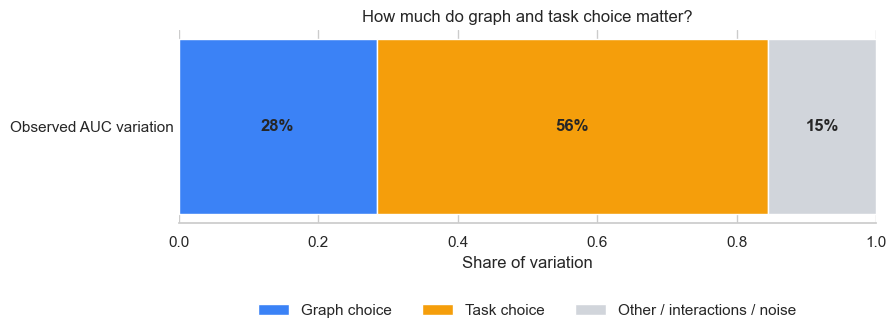

In [259]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# df should be your wide table:
# rows = train graph + task
# columns = evaluation graph + task
# first column = "train_id"

# Convert wide matrix to one row per train/evaluation combination
long = sdf.reset_index().melt(
    id_vars="train_id",
    var_name="test_id",
    value_name="auc"
)

# Split IDs into graph and task using the final "+"
long[["train_graph", "train_task"]] = (
    long["train_id"].str.rsplit("+", n=1, expand=True)
)
long[["test_graph", "test_task"]] = (
    long["test_id"].str.rsplit("+", n=1, expand=True)
)

# Treat the training/evaluation combination as the choice being made
long["graph_choice"] = (
    long["train_graph"] + " → " + long["test_graph"]
)
long["task_choice"] = (
    long["train_task"] + " → " + long["test_task"]
)

long["same_graph"] = long["train_graph"] == long["test_graph"]
long["same_task"] = long["train_task"] == long["test_task"]


def categorical_r2(data, factors):
    """R² from an additive categorical regression."""
    y = data["auc"].to_numpy(float)
    X_parts = [np.ones((len(data), 1))]

    for factor in factors:
        dummies = pd.get_dummies(
            data[factor],
            drop_first=True,
            dtype=float
        )
        if dummies.shape[1] > 0:
            X_parts.append(dummies.to_numpy())

    X = np.column_stack(X_parts)
    coefficients = np.linalg.lstsq(X, y, rcond=None)[0]
    predictions = X @ coefficients

    residual_ss = np.sum((y - predictions) ** 2)
    total_ss = np.sum((y - y.mean()) ** 2)

    return 1 - residual_ss / total_ss


def shapley_r2(data, factors):
    """
    Allocate explained variation fairly among factors by averaging
    each factor's added R² across every possible entry order.
    """
    contributions = {factor: 0.0 for factor in factors}
    orders = list(itertools.permutations(factors))

    for order in orders:
        included = []
        previous_r2 = 0

        for factor in order:
            included.append(factor)
            current_r2 = categorical_r2(data, included)
            contributions[factor] += current_r2 - previous_r2
            previous_r2 = current_r2

    return {
        factor: value / len(orders)
        for factor, value in contributions.items()
    }


# Main graph-versus-task comparison
importance = shapley_r2(
    long,
    ["graph_choice", "task_choice"]
)

graph_share = importance["graph_choice"]
task_share = importance["task_choice"]
unexplained_share = max(0, 1 - graph_share - task_share)

results = pd.DataFrame({
    "Source": [
        "Graph choice",
        "Task choice",
        "Other / interactions / noise"
    ],
    "Share": [
        graph_share,
        task_share,
        unexplained_share
    ]
})

display(
    results.style.format({"Share": "{:.1%}"})
)

print("Within the variation explained by graph and task:")
print(
    f"Graph: {graph_share / (graph_share + task_share):.1%}"
)
print(
    f"Task:  {task_share / (graph_share + task_share):.1%}"
)


# Additional intuitive comparison: benefit of matching
matching = pd.DataFrame({
    "Comparison": ["Same graph", "Same task"],
    "AUC difference": [
        long.loc[long["same_graph"], "auc"].mean()
        - long.loc[~long["same_graph"], "auc"].mean(),

        long.loc[long["same_task"], "auc"].mean()
        - long.loc[~long["same_task"], "auc"].mean()
    ]
})

display(
    matching.style.format({"AUC difference": "{:+.3f}"})
)


# Slide-ready plot
colors = ["#3B82F6", "#F59E0B", "#D1D5DB"]

fig, ax = plt.subplots(figsize=(9, 2.5))
left = 0

for row, color in zip(results.itertuples(), colors):
    ax.barh(
        ["Observed AUC variation"],
        row.Share,
        left=left,
        color=color,
        label=row.Source
    )

    if row.Share >= 0.06:
        ax.text(
            left + row.Share / 2,
            0,
            f"{row.Share:.0%}",
            ha="center",
            va="center",
            fontweight="bold"
        )

    left += row.Share

ax.set_xlim(0, 1)
ax.set_xlabel("Share of variation")
ax.set_title("How much do graph and task choice matter?")
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
    frameon=False
)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.show()

In [260]:
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

factor_cols = [
    "train_graph",
    "train_task",
    "test_graph",
    "test_task",
]

model_data = long.copy()

model_data["auc"] = pd.to_numeric(
    model_data["auc"],
    errors="coerce"
)

model_data = model_data.dropna(
    subset=factor_cols + ["auc"]
)

for col in factor_cols:
    model_data[col] = model_data[col].astype("category")


full_formula = """
auc ~ C(train_graph)
      + C(train_task)
      + C(test_graph)
      + C(test_task)
"""

full_model = smf.ols(full_formula, data=model_data).fit()

without_graph = smf.ols(
    """
    auc ~ C(train_task)
          + C(test_graph)
          + C(test_task)
    """,
    data=model_data
).fit()

without_task = smf.ols(
    """
    auc ~ C(train_graph)
          + C(test_graph)
          + C(test_task)
    """,
    data=model_data
).fit()


results = pd.DataFrame({
    "factor": [
        "Training graph",
        "Training task",
    ],

    # Unique share of all observed AUC variation
    "unique_delta_r2": [
        full_model.rsquared - without_graph.rsquared,
        full_model.rsquared - without_task.rsquared,
    ],

    # Share relative to remaining unexplained variation
    "partial_eta2": [
        (
            full_model.rsquared - without_graph.rsquared
        ) / (
            1 - without_graph.rsquared
        ),
        (
            full_model.rsquared - without_task.rsquared
        ) / (
            1 - without_task.rsquared
        ),
    ],
})

display(
    results.style.format({
        "unique_delta_r2": "{:.1%}",
        "partial_eta2": "{:.3f}",
    })
)

print(f"Full model R²: {full_model.rsquared:.1%}")

,factor,unique_delta_r2,partial_eta2
0,Training graph,0.0%,0.001
1,Training task,39.9%,0.611


Full model R²: 74.6%


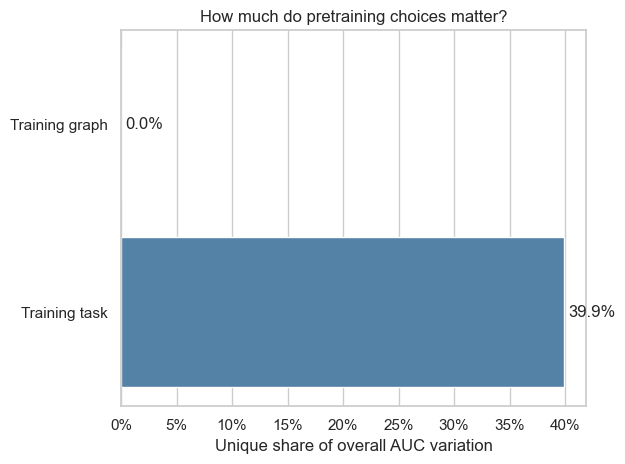

In [261]:
ax = sns.barplot(
    data=results,
    x="unique_delta_r2",
    y="factor",
    color="steelblue"
)

ax.set(
    xlabel="Unique share of overall AUC variation",
    ylabel="",
    title="How much do pretraining choices matter?"
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x:.1%}",
        padding=3
    )

plt.tight_layout()
plt.show()

In [269]:
anova[["sum_sq", "df", "F", "PR(>F)", "partial_eta2"]]

,sum_sq,df,F,PR(>F),partial_eta2
C(train_graph),0.000338,2.0,0.024668,9.756403e-01,0.000514
C(train_task),1.030496,2.0,75.316015,2.141136e-20,0.610756
C(test_graph),0.605328,5.0,17.696677,2.156385e-12,0.479628
C(test_task),0.194819,2.0,14.238763,3.842851e-06,0.228776
Residual,0.656750,96.0,NaN,NaN,0.500000


# Data diversity


Individual sequential models:
                                      sequence_type         final_model  \
train_id                                                                  
covid19_twitter+lp>ukr_rus_twitter+lp         LP>LP  ukr_rus_twitter+lp   
covid19_twitter+nm>ukr_rus_twitter+lp         NM>LP  ukr_rus_twitter+lp   
covid19_twitter+nm>ukr_rus_twitter+nm         NM>NM  ukr_rus_twitter+nm   
midterm+lp>covid19_twitter+lp                 LP>LP  covid19_twitter+lp   
midterm+lp>ukr_rus_twitter+lp                 LP>LP  ukr_rus_twitter+lp   
midterm+nm>covid19_twitter+lp                 NM>LP  covid19_twitter+lp   
midterm+nm>covid19_twitter+nm                 NM>NM  covid19_twitter+nm   
midterm+nm>ukr_rus_twitter+lp                 NM>LP  ukr_rus_twitter+lp   
midterm+nm>ukr_rus_twitter+nm                 NM>NM  ukr_rus_twitter+nm   

                                       mean_effect  median_effect  \
train_id                                                            
covid

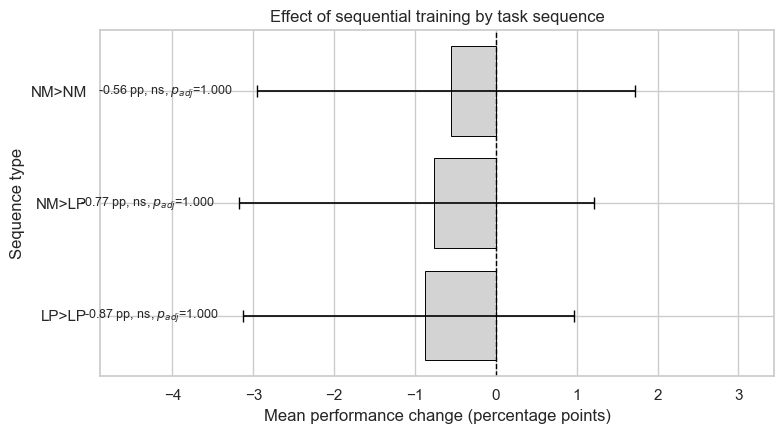

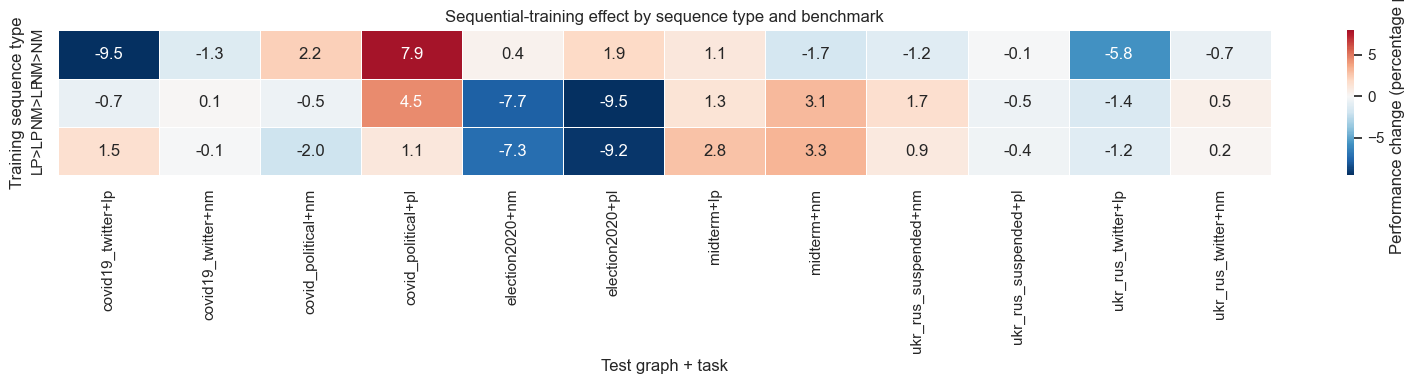

In [364]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


# ============================================================
# 1. Prepare the original dataframe
# ============================================================

id_col = "train_id"
benchmark_cols = df.columns.drop(id_col)

df = df.copy()
df[benchmark_cols] = df[benchmark_cols].apply(
    pd.to_numeric,
    errors="coerce",
)

scores = df.set_index(id_col)[benchmark_cols]

# Select only sequentially trained models
sequential_ids = scores.index[
    scores.index.str.contains(">", regex=False)
]


# ============================================================
# 2. Calculate sequential-training effects
#
# effect(a>b) = score(a>b) - score(b)
# ============================================================

effect_rows = []
metadata_rows = []

for sequential_id in sequential_ids:

    first_model, final_model = sequential_id.rsplit(">", 1)

    if final_model not in scores.index:
        print(
            f"Skipping {sequential_id}: "
            f"baseline {final_model!r} is missing"
        )
        continue

    # Extract task names: nm, lp, pl, ...
    first_task = first_model.rsplit("+", 1)[-1].upper()
    final_task = final_model.rsplit("+", 1)[-1].upper()

    sequence_type = f"{first_task}>{final_task}"

    effect = (
        scores.loc[sequential_id]
        - scores.loc[final_model]
    )

    effect_rows.append(effect.rename(sequential_id))

    metadata_rows.append({
        "train_id": sequential_id,
        "first_model": first_model,
        "final_model": final_model,
        "first_task": first_task,
        "final_task": final_task,
        "sequence_type": sequence_type,
    })


effect_df = pd.DataFrame(effect_rows)
effect_df.index.name = "train_id"

metadata = pd.DataFrame(metadata_rows).set_index("train_id")


# ============================================================
# 3. Keep the requested sequence types
# ============================================================

requested_types = [
    "NM>NM",
    "NM>LP",
    "LP>LP",
]

metadata = metadata[
    metadata["sequence_type"].isin(requested_types)
]

effect_df = effect_df.loc[metadata.index]


# ============================================================
# 4. Show individual sequences and their types
# ============================================================

individual_summary = metadata.copy()

individual_summary["mean_effect"] = effect_df.mean(axis=1)
individual_summary["median_effect"] = effect_df.median(axis=1)
individual_summary["benchmarks_improved"] = (
    effect_df.gt(0).sum(axis=1)
)
individual_summary["benchmarks_hurt"] = (
    effect_df.lt(0).sum(axis=1)
)
individual_summary["win_rate"] = (
    effect_df.gt(0).mean(axis=1)
)

print("\nIndividual sequential models:")
print(
    individual_summary[
        [
            "sequence_type",
            "final_model",
            "mean_effect",
            "median_effect",
            "benchmarks_improved",
            "benchmarks_hurt",
            "win_rate",
        ]
    ].round(4)
)


# ============================================================
# 5. Aggregate within each sequence type
#
# First average all sequences of a type separately for each
# benchmark. The resulting rows contain benchmark-level effects.
# ============================================================

effect_with_type = effect_df.join(
    metadata[["sequence_type"]]
)

type_effects = (
    effect_with_type
    .groupby("sequence_type")[benchmark_cols]
    .mean()
    .reindex(requested_types)
    .dropna(how="all")
)

print("\nAverage effect by sequence type and benchmark:")
print((type_effects * 100).round(2))


# ============================================================
# 6. Wilcoxon tests across benchmarks
#
# H0: median benchmark-level effect equals zero.
# ============================================================

statistical_results = []

for sequence_type, row in type_effects.iterrows():

    differences = row.dropna().to_numpy(dtype=float)

    if len(differences) == 0:
        continue

    if np.allclose(differences, 0):
        statistic = 0.0
        p_value = 1.0
    else:
        test = wilcoxon(
            differences,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto",
        )

        statistic = test.statistic
        p_value = test.pvalue

    source_sequences = metadata.index[
        metadata["sequence_type"] == sequence_type
    ]

    statistical_results.append({
        "sequence_type": sequence_type,
        "n_sequences": len(source_sequences),
        "n_benchmarks": len(differences),
        "mean_effect": differences.mean(),
        "median_effect": np.median(differences),
        "benchmarks_improved": np.sum(differences > 0),
        "benchmarks_hurt": np.sum(differences < 0),
        "win_rate": np.mean(differences > 0),
        "wilcoxon_statistic": statistic,
        "p_value": p_value,
    })


sig_results = pd.DataFrame(statistical_results)

# Correct for testing multiple sequence types
sig_results["p_adjusted"] = multipletests(
    sig_results["p_value"],
    alpha=0.05,
    method="holm",
)[1]

sig_results["significant"] = (
    sig_results["p_adjusted"] < 0.05
)

sig_results = sig_results.sort_values(
    "mean_effect",
    ascending=False,
)

print("\nAggregate statistical results:")
print(sig_results.round(4))


# ============================================================
# 7. Bootstrap confidence intervals across benchmarks
# ============================================================

def bootstrap_mean_ci(values, n_boot=10_000, seed=42):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)

    bootstrap_means = np.empty(n_boot)

    for i in range(n_boot):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True,
        )
        bootstrap_means[i] = sample.mean()

    return np.quantile(
        bootstrap_means,
        [0.025, 0.975],
    )


ci_lookup = {}

for sequence_type, row in type_effects.iterrows():
    differences = row.dropna().to_numpy(dtype=float)
    ci_lookup[sequence_type] = bootstrap_mean_ci(differences)

sig_results["ci_low"] = sig_results["sequence_type"].map(
    lambda x: ci_lookup[x][0]
)

sig_results["ci_high"] = sig_results["sequence_type"].map(
    lambda x: ci_lookup[x][1]
)

print("\nResults with bootstrap confidence intervals:")
print(
    sig_results[
        [
            "sequence_type",
            "n_sequences",
            "mean_effect",
            "ci_low",
            "ci_high",
            "win_rate",
            "p_value",
            "p_adjusted",
            "significant",
        ]
    ].round(4)
)


# ============================================================
# 8. Plot mean effects with confidence intervals
# ============================================================

plot_df = sig_results.sort_values(
    "mean_effect",
    ascending=True,
).copy()

plot_df["effect_pp"] = plot_df["mean_effect"] * 100
plot_df["ci_low_pp"] = plot_df["ci_low"] * 100
plot_df["ci_high_pp"] = plot_df["ci_high"] * 100

plot_df["error_low"] = (
    plot_df["effect_pp"] - plot_df["ci_low_pp"]
)

plot_df["error_high"] = (
    plot_df["ci_high_pp"] - plot_df["effect_pp"]
)

colors = []

for _, row in plot_df.iterrows():
    if not row["significant"]:
        colors.append("lightgray")
    elif row["mean_effect"] > 0:
        colors.append("steelblue")
    else:
        colors.append("firebrick")


fig, ax = plt.subplots(figsize=(8, 4.5))

y = np.arange(len(plot_df))

ax.barh(
    y,
    plot_df["effect_pp"],
    color=colors,
    edgecolor="black",
    linewidth=0.7,
)

ax.errorbar(
    plot_df["effect_pp"],
    y,
    xerr=np.vstack([
        plot_df["error_low"],
        plot_df["error_high"],
    ]),
    fmt="none",
    ecolor="black",
    capsize=4,
    linewidth=1.2,
)

ax.axvline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["sequence_type"])

ax.set_xlabel(
    "Mean performance change "
    "(percentage points)"
)
ax.set_ylabel("Sequence type")
ax.set_title("Effect of sequential training by task sequence")

for position, (_, row) in enumerate(plot_df.iterrows()):

    marker = "*" if row["significant"] else "ns"

    label = (
        f"{row['effect_pp']:+.2f} pp, "
        f"{marker}, "
        f"$p_{{adj}}$={row['p_adjusted']:.3f}"
    )

    label_x = (
        row["ci_high_pp"] + 0.3
        if row["effect_pp"] >= 0
        else row["ci_low_pp"] - 0.3
    )

    ax.text(
        label_x,
        position,
        label,
        va="center",
        ha="left" if row["effect_pp"] >= 0 else "right",
        fontsize=9,
    )

ax.margins(x=0.35)
plt.tight_layout()
plt.show()


# ============================================================
# 9. Optional heatmap: effects by type and benchmark
# ============================================================

import seaborn as sns

plt.figure(figsize=(16, 4))

sns.heatmap(
    type_effects * 100,
    center=0,
    cmap="RdBu_r",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={
        "label": "Performance change (percentage points)"
    },
)

plt.xlabel("Test graph + task")
plt.ylabel("Training sequence type")
plt.title(
    "Sequential-training effect by sequence type and benchmark"
)
plt.tight_layout()
plt.show()

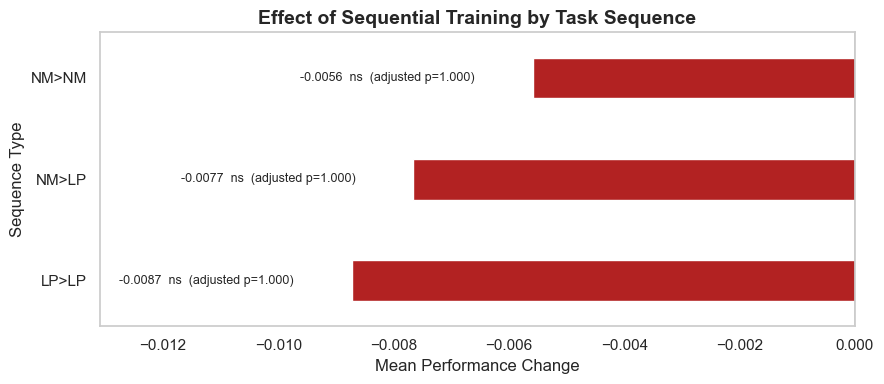

In [377]:
plot_df = sig_results.sort_values("mean_effect")

ax = plot_df.plot.barh(
    x="sequence_type",
    y="mean_effect",
    color="firebrick",
    width=0.4,  # skinnier bars
    legend=False,
    figsize=(9, 4),
)

ax.axvline(0, color="black", linewidth=1)

ax.set_title(
    "Effect of Sequential Training by Task Sequence",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Mean Performance Change")
ax.set_ylabel("Sequence Type")

# Add effect, significance, and adjusted p-value
for bar, (_, row) in zip(ax.patches, plot_df.iterrows()):
    value = row["mean_effect"]
    significance = "*" if row["significant"] else "ns"

    label = (
        f"{value:+.4f}  "
        f"{significance}  "
        f"(adjusted p={row['p_adjusted']:.3f})"
    )

    ax.text(
        value + (0.001 if value >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9,
    )

ax.margins(x=0.5)
ax.grid(False)
plt.tight_layout()
plt.show()

In [367]:
slide_table = sig_results[[
    "sequence_type",
    "n_sequences",
    "mean_effect",
    "ci_low",
    "ci_high",
    "p_adjusted",
    "significant",
]].copy()

for col in ["mean_effect", "ci_low", "ci_high"]:
    slide_table[col] *= 100

slide_table["Result"] = slide_table.apply(
    lambda row: (
        f"{row['mean_effect']:+.2f} pp "
        f"[{row['ci_low']:+.2f}, {row['ci_high']:+.2f}]"
    ),
    axis=1,
)

slide_table["Significance"] = slide_table.apply(
    lambda row: (
        "Significant"
        if row["significant"]
        else "Not significant"
    ),
    axis=1,
)

slide_table = slide_table[[
    "sequence_type",
    "n_sequences",
    "Result",
    "p_adjusted",
    "Significance",
]]

display(slide_table.round({"p_adjusted": 3}))

,sequence_type,n_sequences,Result,p_adjusted,Significance
0,NM>NM,3,"-0.56 pp [-2.95, +1.72]",1.0,Not significant
1,NM>LP,3,"-0.77 pp [-3.18, +1.22]",1.0,Not significant
2,LP>LP,3,"-0.87 pp [-3.13, +0.96]",1.0,Not significant


# data curriculum

In [394]:
import itertools
import numpy as np
import pandas as pd

# df = your dataframe
df_ = df.copy()
df = df.set_index("train_id")
eval_cols = df.columns
df[eval_cols] = df[eval_cols].apply(pd.to_numeric)

comparisons = {
    "nm": {
        "merged": "ukr/cov/mid+nm",
        "singles": [
            "covid19_twitter+nm",
            "midterm+nm",
            "ukr_rus_twitter+nm",
        ],
    },
    "lp": {
        "merged": "ukr/cov/mid+lp",
        "singles": [
            "covid19_twitter+lp",
            "midterm+lp",
            "ukr_rus_twitter+lp",
        ],
    },
}


def exact_sign_flip_test(differences):
    """
    One-sided paired permutation test.

    H0: merging does not improve performance.
    H1: mean(merged - baseline) > 0.
    """
    differences = np.asarray(differences, dtype=float)
    observed = differences.mean()

    null_means = np.array([
        np.mean(differences * signs)
        for signs in itertools.product([-1, 1], repeat=len(differences))
    ])

    p_improvement = np.mean(null_means >= observed)
    p_two_sided = np.mean(np.abs(null_means) >= abs(observed))

    return p_improvement, p_two_sided


results = []

for task, config in comparisons.items():
    merged = df.loc[config["merged"], eval_cols]
    singles = df.loc[config["singles"], eval_cols]

    baselines = {
        # Does merging beat a typical single-graph model?
        "mean_single": singles.mean(axis=0),

        # Does merging beat the strongest available single-graph model?
        "best_single": singles.max(axis=0),
    }

    scopes = {
        "all_evaluations": list(eval_cols),
        "task_matched": [
            col for col in eval_cols
            if col.endswith(f"+{task}")
        ],
    }

    for scope_name, columns in scopes.items():
        for baseline_name, baseline in baselines.items():
            differences = (
                merged.loc[columns] - baseline.loc[columns]
            ).to_numpy()

            p_improvement, p_two_sided = exact_sign_flip_test(differences)

            results.append({
                "training_task": task,
                "scope": scope_name,
                "baseline": baseline_name,
                "n_evaluations": len(columns),
                "merged_mean": merged.loc[columns].mean(),
                "baseline_mean": baseline.loc[columns].mean(),
                "mean_difference": differences.mean(),
                "wins": np.sum(differences > 0),
                "losses": np.sum(differences < 0),
                "p_improvement": p_improvement,
                "p_two_sided": p_two_sided,
            })

results = pd.DataFrame(results)

display(
    results.round(4)
)

df = df_.copy()

,training_task,scope,baseline,n_evaluations,merged_mean,baseline_mean,mean_difference,wins,losses,p_improvement,p_two_sided
0,nm,all_evaluations,mean_single,12,0.7727,0.7807,-0.0080,3,9,0.8826,0.2354
1,nm,all_evaluations,best_single,12,0.7727,0.8049,-0.0322,1,11,0.9988,0.0029
2,nm,task_matched,mean_single,6,0.8545,0.8501,0.0044,3,3,0.4219,0.8438
3,nm,task_matched,best_single,6,0.8545,0.8631,-0.0086,1,5,0.9219,0.1875
4,lp,all_evaluations,mean_single,12,0.6945,0.7339,-0.0394,6,6,0.9302,0.1401
5,lp,all_evaluations,best_single,12,0.6945,0.7931,-0.0986,1,11,0.9998,0.0010
6,lp,task_matched,mean_single,3,0.7693,0.8031,-0.0338,1,2,0.7500,0.7500
7,lp,task_matched,best_single,3,0.7693,0.9033,-0.1340,0,3,1.0000,0.2500


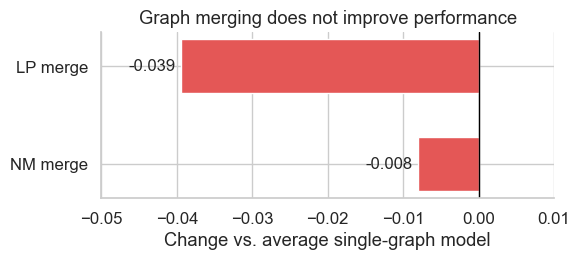

In [397]:
import matplotlib.pyplot as plt
import pandas as pd

plot_data = pd.DataFrame({
    "Model": ["NM merge", "LP merge"],
    "Change": [-0.0080, -0.0394],
})

fig, ax = plt.subplots(figsize=(6, 2.8))

bars = ax.barh(
    plot_data["Model"],
    plot_data["Change"],
    color="#E45756",
    height=0.55,
)

ax.axvline(0, color="black", linewidth=1)
ax.bar_label(bars, fmt="%+.3f", padding=4, fontsize=12)

ax.set_xlabel("Change vs. average single-graph model")
ax.set_title("Graph merging does not improve performance")
ax.set_xlim(-0.05, 0.01)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("graph_merging_horizontal.png", dpi=300, bbox_inches="tight")
plt.show()

In [387]:
df = df.reset_index()

# task curriculum

In [389]:
import numpy as np
import pandas as pd
from scipy import stats

baseline_id = "ukr/cov/mid+nm"
merged_id = "ukr/cov/mid+nm/fm"

score_cols = [c for c in df.columns if c != "train_id"]

baseline = (
    df.loc[df["train_id"] == baseline_id, score_cols]
      .iloc[0]
      .astype(float)
)

merged = (
    df.loc[df["train_id"] == merged_id, score_cols]
      .iloc[0]
      .astype(float)
)

results = pd.DataFrame({
    "baseline_nm": baseline,
    "merged_nm_fm": merged,
})

results["difference"] = (
    results["merged_nm_fm"] - results["baseline_nm"]
)

summary = {
    "baseline_mean": baseline.mean(),
    "merged_mean": merged.mean(),
    "mean_improvement": results["difference"].mean(),
    "median_improvement": results["difference"].median(),
    "relative_improvement_pct": (
        100 * results["difference"].mean() / baseline.mean()
    ),
    "improved_evals": (results["difference"] > 0).sum(),
    "worsened_evals": (results["difference"] < 0).sum(),
    "number_of_evals": len(results),
}

# Primary non-parametric paired test
wilcoxon = stats.wilcoxon(
    merged,
    baseline,
    alternative="two-sided",
    method="exact",
)

# Tests only whether the direction of change is consistently positive
sign_test = stats.binomtest(
    (results["difference"] > 0).sum(),
    n=len(results),
    p=0.5,
    alternative="two-sided",
)

# Optional parametric estimate and confidence interval
ttest = stats.ttest_rel(merged, baseline)
ci = ttest.confidence_interval(confidence_level=0.95)

print(pd.Series(summary))
print("\nPer-evaluation differences:")
display(results.sort_values("difference", ascending=False))

print(f"\nWilcoxon p-value: {wilcoxon.pvalue:.4f}")
print(f"Sign-test p-value: {sign_test.pvalue:.4f}")
print(f"Paired t-test p-value: {ttest.pvalue:.4f}")
print(f"95% CI for mean difference: ({ci.low:.4f}, {ci.high:.4f})")

baseline_mean                0.772667
merged_mean                  0.863667
mean_improvement             0.091000
median_improvement           0.052500
relative_improvement_pct    11.777394
improved_evals              10.000000
worsened_evals               2.000000
number_of_evals             12.000000
dtype: float64

Per-evaluation differences:


,baseline_nm,merged_nm_fm,difference
covid_political+pl,0.597,0.877,0.280
election2020+pl,0.730,0.979,0.249
covid_political+nm,0.717,0.900,0.183
election2020+nm,0.713,0.888,0.175
ukr_rus_twitter+lp,0.772,0.878,0.106
ukr_rus_suspended+nm,0.780,0.841,0.061
ukr_rus_suspended+pl,0.488,0.532,0.044
midterm+lp,0.740,0.763,0.023
covid19_twitter+lp,0.818,0.830,0.012
covid19_twitter+nm,0.990,0.991,0.001



Wilcoxon p-value: 0.0122
Sign-test p-value: 0.0386
Paired t-test p-value: 0.0127
95% CI for mean difference: (0.0236, 0.1584)


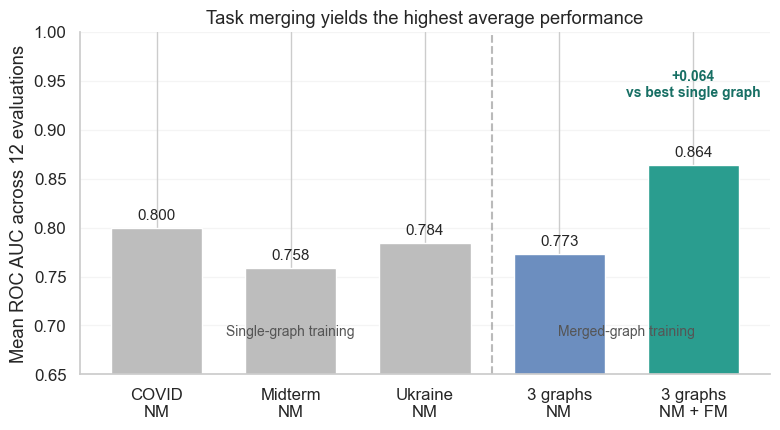

In [400]:
import matplotlib.pyplot as plt

models = [
    "covid19_twitter+nm",
    "midterm+nm",
    "ukr_rus_twitter+nm",
    "ukr/cov/mid+nm",
    "ukr/cov/mid+nm/fm",
]

labels = [
    "COVID\nNM",
    "Midterm\nNM",
    "Ukraine\nNM",
    "3 graphs\nNM",
    "3 graphs\nNM + FM",
]

means = (
    df.set_index("train_id")
      .loc[models]
      .astype(float)
      .mean(axis=1)
)

colors = [
    "#BDBDBD",
    "#BDBDBD",
    "#BDBDBD",
    "#6C8EBF",
    "#2A9D8F",
]

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    labels,
    means,
    color=colors,
    width=0.68,
)

ax.bar_label(
    bars,
    labels=[f"{v:.3f}" for v in means],
    padding=4,
    fontsize=11,
)

# Difference from the best single-graph NM model
best_single = means.iloc[:3].max()
merged_tasks = means.iloc[-1]

ax.text(
    4,
    merged_tasks + 0.07,
    f"+{merged_tasks - best_single:.3f}\nvs best single graph",
    ha="center",
    fontsize=10,
    weight="bold",
    color="#176F64",
)

ax.axvline(2.5, color="#777777", linestyle="--", alpha=0.5)

ax.text(
    1,
    0.69,
    "Single-graph training",
    ha="center",
    fontsize=10,
    color="#555555",
)

ax.text(
    3.5,
    0.69,
    "Merged-graph training",
    ha="center",
    fontsize=10,
    color="#555555",
)

ax.set_ylabel("Mean ROC AUC across 12 evaluations")
ax.set_ylim(0.65, 1.0)
ax.set_title("Task merging yields the highest average performance")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    "task_and_graph_merging_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()